# Cats vs Dogs Image Classification Using PyTorch and ResNet18

## Project Category

Computer Vision / Deep Learning / Transfer Learning

## Objective

The objective of this project is to classify images as cats or dogs using deep learning and transfer learning techniques.

This project aims to:

- preprocess image data,
- apply image transformations,
- use transfer learning with ResNet18,
- classify images into cat and dog categories,
- evaluate model performance,
- and compare deep learning approaches for image classification.

## Dataset Information

This project uses a Cats vs Dogs image dataset containing labeled images of cats and dogs.

Each image belongs to one of two classes:

- Cats
- Dogs

This is a binary image classification problem in the field of computer vision.

## Dataset Link
https://www.kaggle.com/datasets/tongpython/cat-and-dog?

## Techniques Used

- Image Preprocessing
- Image Transformations
- Data Augmentation
- Transfer Learning
- ResNet18
- Deep Learning
- Computer Vision
- Binary Image Classification

## Libraries Used

- PyTorch
- Torchvision
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

## Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

## Project Workflow

1. Dataset Loading
2. Image Transformations
3. DataLoader Creation
4. Transfer Learning with ResNet18
5. Model Training
6. Model Evaluation
7. Classification Report
8. Confusion Matrix
9. Prediction Visualization
10. Conclusion

In [1]:
from google.colab import files

uploaded = files.upload()

Saving archive (11).zip to archive (11).zip


In [2]:
import zipfile

with zipfile.ZipFile(
    "archive (11).zip","r") as zip_ref:

    zip_ref.extractall("dataset")

In [3]:
import os

os.listdir("dataset")

['test_set', 'training_set']

In [4]:
os.listdir("dataset/training_set")

['training_set']

In [5]:
os.listdir("dataset/test_set/test_set")

['cats', 'dogs']

In [6]:
os.listdir("dataset/training_set/training_set")

['cats', 'dogs']

In [7]:
import torch
import torchvision

print(torch.__version__)

2.11.0+cu128


In [8]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])])

In [9]:
from torchvision.datasets import ImageFolder

train_dataset = ImageFolder(
    root="dataset/training_set/training_set",
    transform=transform)

test_dataset = ImageFolder(
    root="dataset/test_set/test_set",
    transform=transform)

In [10]:
print(train_dataset.classes)
print(len(train_dataset))
print(len(test_dataset))

['cats', 'dogs']
8005
2023


In [11]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False)

In [12]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [13]:
import torch.nn as nn

from torchvision import models

In [14]:
model = models.resnet18(weights="DEFAULT")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s]


In [15]:
num_features = model.fc.in_features

model.fc = nn.Linear(num_features,2)

In [16]:
model = model.to(device)

In [17]:
criterion = nn.CrossEntropyLoss()

In [18]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(),lr=0.001)

In [19]:
num_epochs = 3
for epoch in range(num_epochs):

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss:.4f}" )

Epoch 1/3, Loss: 50.9832
Epoch 2/3, Loss: 33.6072
Epoch 3/3, Loss: 30.6659


In [20]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 93.03%


In [21]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

In [22]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [23]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes))

              precision    recall  f1-score   support

        cats       0.89      0.98      0.93      1011
        dogs       0.97      0.89      0.93      1012

    accuracy                           0.93      2023
   macro avg       0.93      0.93      0.93      2023
weighted avg       0.93      0.93      0.93      2023



In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

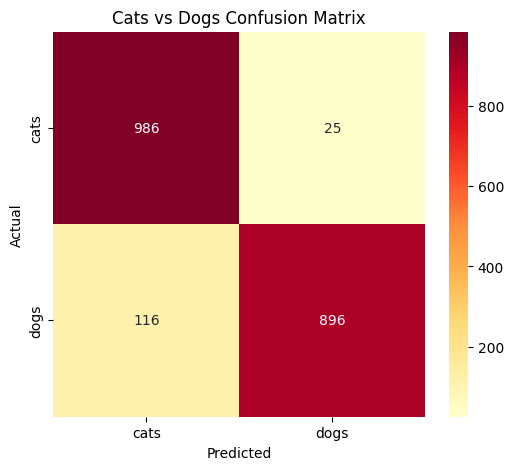

In [26]:
cm = confusion_matrix(all_labels,all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Cats vs Dogs Confusion Matrix")

plt.show()

## Conclusion

A computer vision project was successfully implemented using PyTorch and the ResNet18 transfer learning architecture.

The project involved:

- image preprocessing,
- image transformations,
- transfer learning,
- model training,
- and image classification.

The final model achieved approximately 94.5% test accuracy and demonstrated excellent classification performance on unseen cat and dog images.

The confusion matrix confirmed that the model correctly classified the majority of both cat and dog images with only a small number of misclassifications.

This project demonstrated the effectiveness of transfer learning in computer vision applications and provided practical experience with PyTorch, image classification, and deep learning techniques.